In [1]:
import numpy as np
import scipy.special as scp
import matplotlib.pyplot as plt

plt.style.use('../include/aps.mplstyle')

In [2]:
GPdata = np.load('../data/GPGP3.npy')
MDdata = np.load('../data/GPMD3.npy')

In [3]:
Error = np.abs(GPdata - MDdata)
MAE = np.mean(Error)
StE = np.std(Error)/np.sqrt(len(Error))

In [5]:
with plt.style.context('../include/aps.mplstyle'):
    figsize = plt.rcParams['figure.figsize']
    fig,ax = plt.subplots(1,1,figsize=(figsize[0],figsize[1]), constrained_layout=True)
    sc = ax.scatter(MDdata,GPdata,c=Error,cmap='summer')
    ax.plot(MDdata,MDdata,'k-')
    ax.set_xlabel('MD Data [K]')
    ax.set_ylabel('GP Prediction [K]')
    ax.text(-70,300,s = rf'SMAE = ${MAE:.2f} \pm {StE:.2f}$ K') 
    ax.set_ylim(GPdata.min(),400)
    ax.set_xlim(MDdata.min(),MDdata.max())
    fig.colorbar(sc, ax=ax)
    #plt.show()
    plt.savefig('../figures/GPParity.pdf')

In [14]:
lscaledata = np.load('../data/lengthscales.npy')
oscaledata = np.load('../data/outputscales.npy')

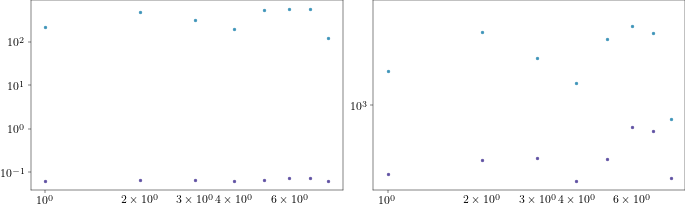

In [21]:
with plt.style.context('../include/aps.mplstyle'):
    figsize = plt.rcParams['figure.figsize']
    fig,ax = plt.subplots(1,2,figsize=(2*figsize[0],figsize[1]), constrained_layout=True)
    ax[0].loglog(lscaledata,'o')
    ax[1].loglog(oscaledata,'o')
    plt.show()